# Comparing distribution and fluctuations of cell features

In this notebook we plot and compare the distributions of numerical and experimental observables:
Here, we plot distributions of the cell features and their fluctuations:
 - $h$, height
 - $A$, area
 - $V$, volume
 - $p_{xy}$, planar aspect ratio
 - $p_h$, vertical aspect ratio
 - $v$, speed

For each observable we do 4 plots: 
 - The experimental distribution at several cell densities, rescaled by the density mean
 - The simulation distribution at several cell densities, rescaled by the density mean
 - The distribution mean of both numerical and experimental datam, plotted against cell number density
 - The mean standard deviation over all datasets/simulation runs, plotted against cell numbert density.




In [1]:
import sys
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

sys.path.append("utils/")
sys.path.append("analysis/visualisation/")
import io_functions as io
import vm_observables as get

from paths_config import SIM_RAW_DIR
from vm_calibration import cell_density_from_Ngrid
from plot_observable_distribution import plot_observable_by_density

In [2]:
def initialise_figure(attr):
    mosaic = [['exp', 'mean', 'std'], 
              ['sim', 'mean', 'std']]

    fig, ax = plt.subplot_mosaic(mosaic, figsize=(10,3))

    ax['exp'].set(ylabel=rf"$P({attr})$")
    ax['sim'].set(ylabel=rf"$P({attr})$",
                  xlabel=rf"${attr}~/~\langle {attr} \rangle$")
    ax['std'].set(xlabel=rf"$\langle {attr} \rangle$",
                  ylabel=rf"$\sigma_{{{attr}}}$")
    ax['mean'].set(xlabel=r"$\rho$",
                   ylabel=rf"$\langle {attr} \rangle$")

    ax['sim'].sharey(ax['exp'])

    return fig, ax

In [3]:
full_experiments = io.load_full_experiments()

State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240301_B1-4_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240301_B2-6_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240317_B1-1_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240319_A1-9_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240319_A1-13_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240319_A1-18_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240319_B1-11_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240516_A2-1_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240516_A2-7_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MDCK_20240516_B1-9_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/exp/raw/MD

In [4]:
mode    = "constant_volume"
params  = "gamma18_v0100_taup175_eta50"
dirpath = f"{SIM_RAW_DIR}/{mode}/{params}/"

Ngrids    = np.array([36, 42, 48, 54])
densities = np.array([1400, 1900, 2450, 3100])

vms_by_density = []
exps_by_density = []

for Ngrid, density in zip(Ngrids,
                          densities):
    vms  = io.load_simulation_ensemble(dirpath, Ngrid=Ngrid)
    exps = io.load_experiments_at_density(full_experiments, density=density)

    vms_by_density.append(vms)
    exps_by_density.append(exps)

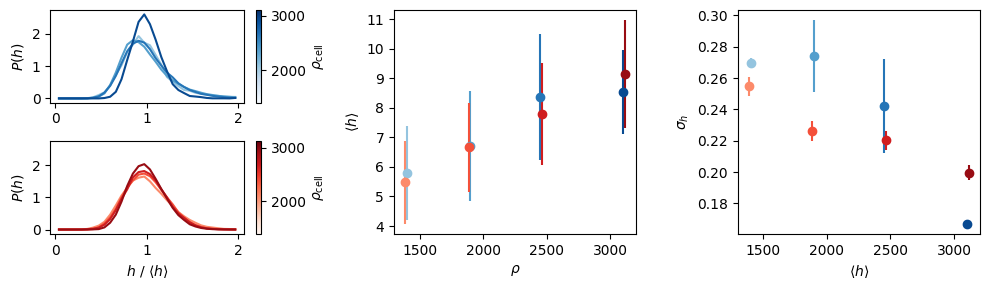

In [5]:
attr = "h"
func = get.cell_heights

fig, ax = initialise_figure(attr)

axs_exp = [ax['exp'], ax['mean'], ax['std']]
axs_sim = [ax['sim'], ax['mean'], ax['std']]

plot_observable_by_density(axs_exp, ds_by_density=exps_by_density, 
                                    densities=densities,
                                    attr=attr,
                                    cmap="Blues",
                                    bins=32,
                                    hist_range=(0.01, 2))

plot_observable_by_density(axs_sim, ds_by_density=vms_by_density,
                                    densities=cell_density_from_Ngrid(Ngrids),
                                    func=func,
                                    cmap="Reds",
                                    bins=32,
                                    hist_range=(0.01, 2))

fig.tight_layout()

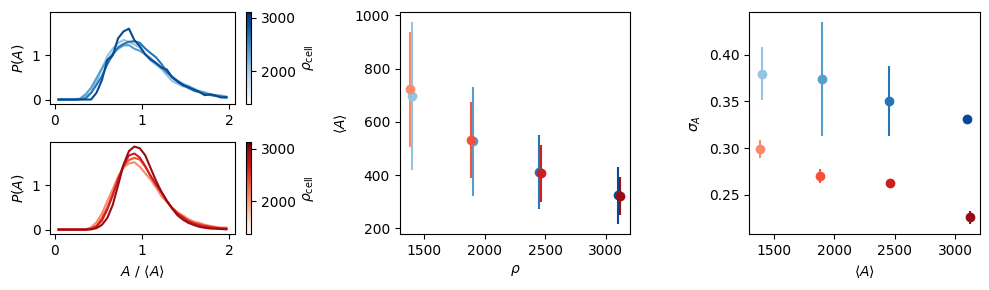

In [6]:
attr = "A"
func = get.cell_areas

fig, ax = initialise_figure(attr)

axs_exp = [ax['exp'], ax['mean'], ax['std']]
axs_sim = [ax['sim'], ax['mean'], ax['std']]

plot_observable_by_density(axs_exp, ds_by_density=exps_by_density, 
                                    densities=densities,
                                    attr=attr,
                                    cmap="Blues",
                                    bins=32,
                                    hist_range=(0.01, 2))

plot_observable_by_density(axs_sim, ds_by_density=vms_by_density,
                                    densities=cell_density_from_Ngrid(Ngrids),
                                    func=func,
                                    cmap="Reds",
                                    bins=32,
                                    hist_range=(0.01, 2))

fig.tight_layout()

/home/silja/Documents/VertexModel/venv/lib/python3.10/site-packages/numpy/ma/core.py:1065: RuntimeWarning: overflow encountered in multiply
  result = self.f(da, db, *args, **kwargs)


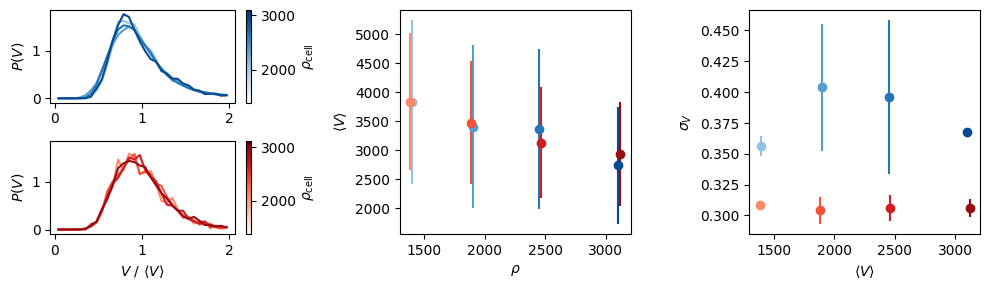

In [7]:
attr = "V"
func = get.cell_volumes

fig, ax = initialise_figure(attr)

axs_exp = [ax['exp'], ax['mean'], ax['std']]
axs_sim = [ax['sim'], ax['mean'], ax['std']]

plot_observable_by_density(axs_exp, ds_by_density=exps_by_density, 
                                    densities=densities,
                                    attr=attr,
                                    cmap="Blues",
                                    bins=32,
                                    hist_range=(0.01, 2))

plot_observable_by_density(axs_sim, ds_by_density=vms_by_density,
                                    densities=cell_density_from_Ngrid(Ngrids),
                                    func=func,
                                    cmap="Reds",
                                    bins=32,
                                    hist_range=(0.01, 2))

fig.tight_layout()

/home/silja/Documents/VertexModel/venv/lib/python3.10/site-packages/numpy/ma/core.py:1208: RuntimeWarning: overflow encountered in divide
  result = self.f(da, db, *args, **kwargs)
/home/silja/Documents/VertexModel/venv/lib/python3.10/site-packages/numpy/ma/core.py:1228: RuntimeWarning: invalid value encountered in multiply
  masked_da = umath.multiply(m, da)


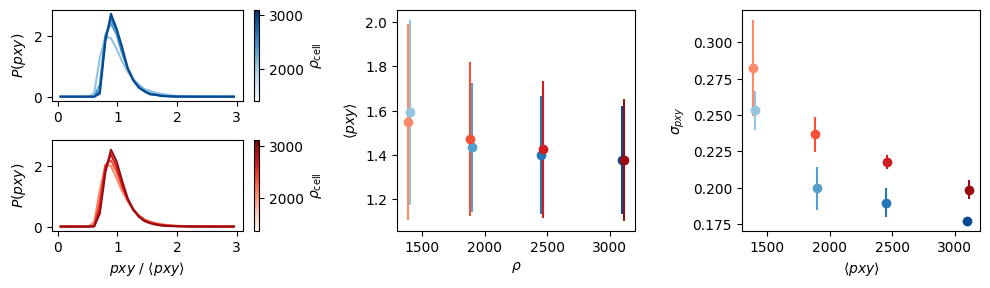

In [8]:
attr = "pxy"
func = get.cell_planar_aspect_ratios

fig, ax = initialise_figure(attr)

axs_exp = [ax['exp'], ax['mean'], ax['std']]
axs_sim = [ax['sim'], ax['mean'], ax['std']]

plot_observable_by_density(axs_exp, ds_by_density=exps_by_density, 
                                    densities=densities,
                                    attr=attr,
                                    cmap="Blues",
                                    bins=32,
                                    hist_range=(1e-4, 3))

plot_observable_by_density(axs_sim, ds_by_density=vms_by_density,
                                    densities=cell_density_from_Ngrid(Ngrids),
                                    func=func,
                                    cmap="Reds",
                                    bins=32,
                                    hist_range=(1e-4, 3))

fig.tight_layout()

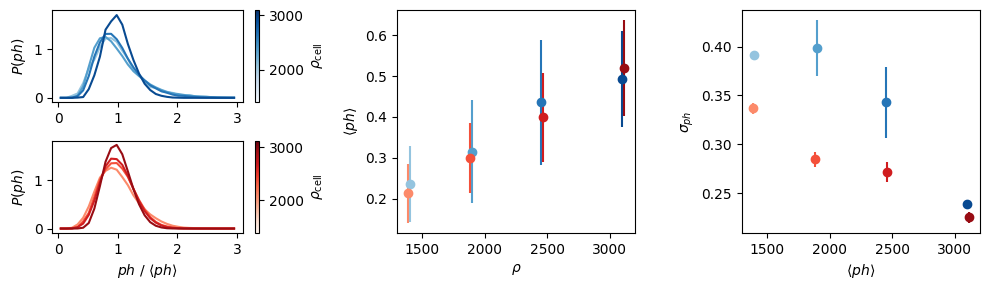

In [9]:
attr = "ph"
func = get.cell_vertical_aspect_ratios

fig, ax = initialise_figure(attr)

axs_exp = [ax['exp'], ax['mean'], ax['std']]
axs_sim = [ax['sim'], ax['mean'], ax['std']]

plot_observable_by_density(axs_exp, ds_by_density=exps_by_density, 
                                    densities=densities,
                                    attr=attr,
                                    cmap="Blues",
                                    bins=32,
                                    hist_range=(1e-4, 3))

plot_observable_by_density(axs_sim, ds_by_density=vms_by_density,
                                    densities=cell_density_from_Ngrid(Ngrids),
                                    func=func,
                                    cmap="Reds",
                                    bins=32,
                                    hist_range=(1e-4, 3))

fig.tight_layout()

/home/silja/Documents/VertexModel/venv/lib/python3.10/site-packages/numpy/ma/core.py:7229: RuntimeWarning: overflow encountered in power
  result = np.where(m, fa, umath.power(fa, fb)).view(basetype)


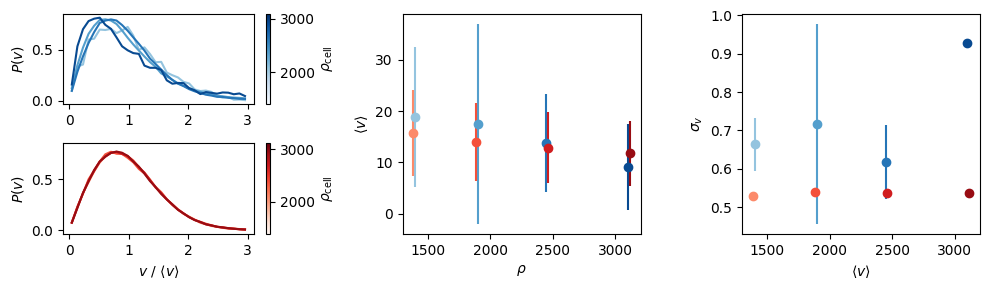

In [10]:
attr = "v"
func = get.cell_speeds

fig, ax = initialise_figure(attr)

axs_exp = [ax['exp'], ax['mean'], ax['std']]
axs_sim = [ax['sim'], ax['mean'], ax['std']]

plot_observable_by_density(axs_exp, ds_by_density=exps_by_density, 
                                    densities=densities,
                                    attr=attr,
                                    cmap="Blues",
                                    bins=32,
                                    hist_range=(1e-4, 3))

plot_observable_by_density(axs_sim, ds_by_density=vms_by_density,
                                    densities=cell_density_from_Ngrid(Ngrids),
                                    func=func,
                                    cmap="Reds",
                                    bins=32,
                                    hist_range=(1e-4, 3))

fig.tight_layout()